# Consumer Complaint EDA

Wells Fargo complaints received from January 2024 to February 2026. This is the prepared eight-category subset, with previously identified duplicate narratives and cross-company matches already removed.

The task this dataset supports is routing: given the complaint narrative alone, predict its product category. Every check below asks whether the text and the label can support that.

Source: [CFPB narrative archive](https://www.consumerfinance.gov/foia-requests/foia-electronic-reading-room/cfpb-consumer-complaint-database-narratives-archive/).

## Load Data

In [1]:
import re
from collections import Counter
from textwrap import fill

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

%matplotlib inline
pd.set_option("display.max_colwidth",120)

df=pd.read_csv("original_dataset.csv",dtype={"Complaint ID":"string","Narrative group ID":"string"})
text_col="Consumer complaint narrative"

BLUE="#2a78d6"
SERIES=["#2a78d6","#eb6834","#1baf7a","#eda100","#e87ba4","#008300"]
GREY="#8a8984"
GRID="#e5e4e0"
plt.rcParams.update({"figure.dpi":110,"font.size":9,"axes.spines.top":False,
                     "axes.spines.right":False,"axes.edgecolor":GRID})

REDACTION=re.compile(r"X{2,}")

## Basic Inspection

In [2]:
print("Shape:",df.shape)
print("Columns:",df.columns.tolist())
display(df.head(3))
df.info()

Shape: (16883, 7)
Columns: ['Complaint ID', 'Date received', 'Company', 'Consumer complaint narrative', 'Product', 'Narrative group ID', 'Source URL']


,Complaint ID,Date received,Company,Consumer complaint narrative,Product,Narrative group ID,Source URL
0,8086745,2024-01-01,WELLS FARGO & COMPANY,Dates and amount and I can't access the account number on my pay stubs,Checking or savings account,b62fe9d43f8728795779bc0646102bc80506e8125acffb11d9c06ae788335583,https://files.consumerfinance.gov/f/documents/CCDB_Export_5_September_2023_through_March_2024.zip
1,8086648,2024-01-01,WELLS FARGO & COMPANY,"More than 3 months ago I requested a XXXXXXXX XXXX XXXX to my bank Welss Fargo, due a system restrictions from them ...",Checking or savings account,e1edc1db3585a88ab494a8343ff8c6dea1b3ee1839a155bf5f8f207e9a40b428,https://files.consumerfinance.gov/f/documents/CCDB_Export_5_September_2023_through_March_2024.zip
2,8086531,2024-01-01,WELLS FARGO & COMPANY,On XX/XX/2023 I received a cashiers check in the mail from Wells Fargo with a letter stating I was overcharged for f...,"Money transfer, virtual currency, or money service",c1545197fabbc9a0505e37019b079c4d6c158b9fafbea811d75a37974f53ab69,https://files.consumerfinance.gov/f/documents/CCDB_Export_5_September_2023_through_March_2024.zip


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16883 entries, 0 to 16882
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Complaint ID                  16883 non-null  string
 1   Date received                 16883 non-null  object
 2   Company                       16883 non-null  object
 3   Consumer complaint narrative  16883 non-null  object
 4   Product                       16883 non-null  object
 5   Narrative group ID            16883 non-null  string
 6   Source URL                    16883 non-null  object
dtypes: object(5), string(2)
memory usage: 923.4+ KB


In [3]:
display(df.nunique().rename("unique_values").to_frame())

,unique_values
Complaint ID,16883
Date received,757
Company,1
Consumer complaint narrative,16883
Product,8
Narrative group ID,16883
Source URL,11


The narrative contains the complaint text and Product contains its category. IDs, dates, narrative group IDs and source links are retained for reference. Company has one value, so it carries no information here. Issue, sub-product and state columns are not present in this file.

Sub-product, issue and sub-issue were excluded during preparation on purpose. In the published CFPB data each of those is close to a deterministic function of Product, so keeping them would let a later model recover the label without reading the narrative.

## Data Quality

In [4]:
quality=pd.DataFrame({
    "missing":df.isna().sum(),
    "empty_or_whitespace":df.apply(lambda col:col.astype("string").str.strip().eq("").sum())
})
display(quality)

text=df[text_col].astype("string")
missing_markers=["na","n/a","null","none","nan","not provided"]
print("Narratives containing only a missing-value marker:",text.str.strip().str.casefold().isin(missing_markers).sum())

,missing,empty_or_whitespace
Complaint ID,0,0
Date received,0,0
Company,0,0
Consumer complaint narrative,0,0
Product,0,0
Narrative group ID,0,0
Source URL,0,0


Narratives containing only a missing-value marker: 0


In [5]:
normalized=text.str.replace(r"\s+"," ",regex=True).str.strip()
duplicate_counts=pd.Series({
    "exact_rows":df.duplicated().sum(),
    "complaint_ids":df["Complaint ID"].duplicated().sum(),
    "exact_narratives":text.duplicated().sum(),
    "narratives_ignoring_case_and_whitespace":normalized.str.casefold().duplicated().sum(),
    "narrative_group_ids":df["Narrative group ID"].duplicated().sum()
},name="duplicates")
display(duplicate_counts.to_frame())
print("Narratives changed by whitespace normalization:",text.ne(normalized).sum())

,duplicates
exact_rows,0
complaint_ids,0
exact_narratives,0
narratives_ignoring_case_and_whitespace,0
narrative_group_ids,0


Narratives changed by whitespace normalization: 10115


In [6]:
dates=pd.to_datetime(df["Date received"],format="%Y-%m-%d",errors="coerce")
label_variants=df.groupby(df["Product"].str.strip().str.casefold())["Product"].nunique()
checks=pd.Series({
    "invalid_dates":dates.isna().sum(),
    "product_labels_with_case_or_whitespace_variants":label_variants.gt(1).sum(),
    "product_labels_with_edge_whitespace":df["Product"].ne(df["Product"].str.strip()).sum(),
    "non_numeric_complaint_ids":(~df["Complaint ID"].str.fullmatch(r"\d+")).sum(),
    "invalid_narrative_group_ids":(~df["Narrative group ID"].str.fullmatch(r"[0-9a-f]{64}")).sum(),
    "non_CFPB_source_links":(~df["Source URL"].str.startswith("https://files.consumerfinance.gov/")).sum()
},name="count")
display(checks.to_frame())
print("Date range:",dates.min().date(),"to",dates.max().date())

,count
invalid_dates,0
product_labels_with_case_or_whitespace_variants,0
product_labels_with_edge_whitespace,0
non_numeric_complaint_ids,0
invalid_narrative_group_ids,0
non_CFPB_source_links,0


Date range: 2024-01-01 to 2026-02-02


Every integrity check is zero. The preparation step already removed duplicate normalized narratives, so the remaining duplicate counts confirm that rather than discovering it.

## Complaint Text Inspection

In [7]:
original_lengths=pd.DataFrame({
    "characters":text.str.len(),
    "words":text.str.split().str.len()
})
display(original_lengths.describe(percentiles=[.5,.9,.95,.99]).round(1))
print("Complaints with fewer than 10 words:",original_lengths["words"].lt(10).sum())
print("Complaints with redaction markers:",text.str.contains(r"\bX{2,}\b",regex=True).sum())
print("Complaints with literal \\n sequences:",text.str.contains(r"\n",regex=False).sum())

,characters,words
count,16883.0,16883.0
mean,1361.3,238.5
std,1488.9,257.0
min,17.0,2.0
50%,965.0,172.0
90%,2799.2,484.0
95%,3864.8,662.0
99%,7302.5,1250.2
max,25970.0,4089.0


Complaints with fewer than 10 words: 75
Complaints with redaction markers: 14806
Complaints with literal \n sequences: 89


In [8]:
examples=df[["Complaint ID","Product"]].join(original_lengths)
examples["preview"]=text.str.slice(0,300)
print("Shortest complaints")
display(examples.nsmallest(5,"words"))
print("Longest complaints (first 300 characters)")
display(examples.nlargest(3,"words"))

Shortest complaints


,Complaint ID,Product,characters,words,preview
3726,9432537,Checking or savings account,17,2,Overdraft charges
857,8339775,Checking or savings account,27,4,Overdrafts fees and charges
2194,8818225,Checking or savings account,23,4,Wells Fargo over charge
2838,9091505,Checking or savings account,31,4,Wellsfargo abuse overdraft fees
2686,9027503,Checking or savings account,38,5,note previous issue still unresolved..


Longest complaints (first 300 characters)


,Complaint ID,Product,characters,words,preview
16177,18398627,Credit card,25970,4089,"Wells Fargo exhibits consistent and deliberate dishonest and fraudulent behavior, including disingenuousness, neglig..."
16017,18302154,Checking or savings account,23901,4081,"To : Consumer Financial Protection Bureau, Wells Fargo and potential customers seeking or presently dealing with Wel..."
9132,12364671,Checking or savings account,21316,3917,XXXX XXXX XXXX XXXX XXXX XXXX OK XXXX XXXX XXXX \nCONSUMER FINANCIAL PROTECTION BUREAU\nConsumer Financial Protecti...


Short complaints include meaningful phrases such as "Overdraft charges" and "Wells Fargo over charge", so length alone is not a reason to remove them. Only 75 complaints fall below ten words. At the other end a single complaint runs to 4,089 words. The 89 narratives containing literal escape sequences are retained as published.

## Data Cleaning

No rows need removal based on the missing-value and duplicate checks. Normalize whitespace only. Keep the original wording, capitalization, punctuation, numbers and redaction markers, since a routing model should see the text as consumers wrote it.

In [9]:
cleaned=df.copy()
cleaned[text_col]=cleaned[text_col].str.replace(r"\s+"," ",regex=True).str.strip()
changed=df[text_col].ne(cleaned[text_col])
print("Narratives with whitespace changes:",changed.sum())
print("Rows removed:",len(df)-len(cleaned))

cleaned["word_count"]=cleaned[text_col].str.split().str.len()
cleaned["month"]=pd.to_datetime(cleaned["Date received"]).dt.to_period("M").dt.to_timestamp()

Narratives with whitespace changes: 10115
Rows removed: 0


## Complaint Lengths

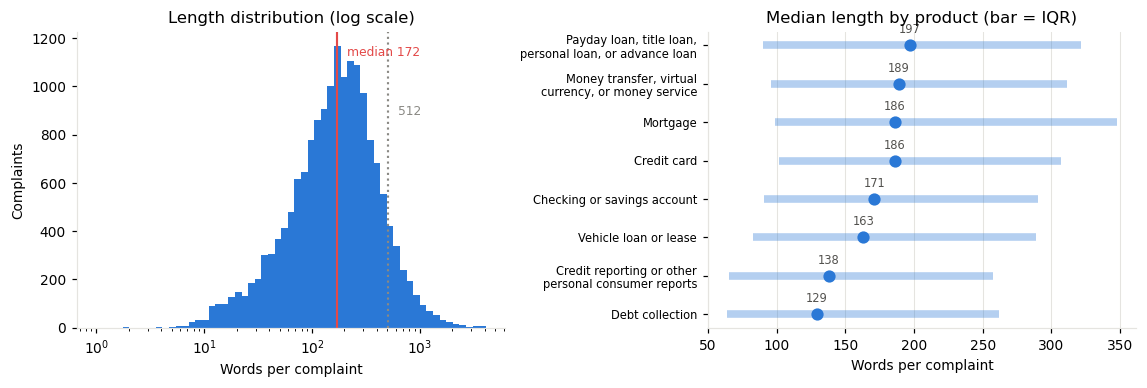

Complaints longer than 512 words: 1528 (9.1% - these get truncated by a 512-token model)
Median length spread across products: 1.5x


In [10]:
words=cleaned["word_count"]
fig,axes=plt.subplots(1,2,figsize=(10.5,3.6))

axes[0].hist(words,bins=np.logspace(0,np.log10(words.max()),60),color=BLUE)
axes[0].set_xscale("log")
axes[0].set_title("Length distribution (log scale)")
axes[0].set_xlabel("Words per complaint")
axes[0].set_ylabel("Complaints")
for q,style in [(words.median(),"-"),(512,":")]:
    axes[0].axvline(q,color="#e34948" if style=="-" else GREY,ls=style,lw=1.4)
axes[0].annotate(f"median {words.median():.0f}",(words.median(),axes[0].get_ylim()[1]*.92),
                 xytext=(6,0),textcoords="offset points",fontsize=8,color="#e34948")
axes[0].annotate("512",(512,axes[0].get_ylim()[1]*.72),xytext=(6,0),
                 textcoords="offset points",fontsize=8,color=GREY)

med=cleaned.groupby("Product")["word_count"].median().sort_values()
q1=cleaned.groupby("Product")["word_count"].quantile(.25).reindex(med.index)
q3=cleaned.groupby("Product")["word_count"].quantile(.75).reindex(med.index)
y=np.arange(len(med))
axes[1].hlines(y,q1.values,q3.values,color=BLUE,lw=5,alpha=.35)
axes[1].plot(med.values,y,"o",color=BLUE,ms=7)
axes[1].set_yticks(y,[fill(l,30) for l in med.index],fontsize=7.5)
axes[1].set_title("Median length by product (bar = IQR)")
axes[1].set_xlabel("Words per complaint")
axes[1].xaxis.grid(True,color=GRID,lw=.7)
axes[1].set_axisbelow(True)
for yi,v in zip(y,med.values):
    axes[1].annotate(f"{v:.0f}",(v,yi),xytext=(0,8),textcoords="offset points",
                     ha="center",fontsize=7.5,color="#52514e")
plt.tight_layout()
plt.show()

print("Complaints longer than 512 words:",int(words.gt(512).sum()),
      f"({words.gt(512).mean()*100:.1f}% - these get truncated by a 512-token model)")
print("Median length spread across products:",f"{med.max()/med.min():.1f}x")

Length is strongly right-skewed, which is why the log scale is used. The practical consequence is the 512-word marker: 1,528 complaints (9.1%) exceed it and would be truncated by a model with a 512-token limit, so either the truncation is accepted or a longer-context approach is needed.

The second panel is the check that matters for routing. Median length varies only 1.5x across the eight categories and the interquartile ranges overlap heavily, so length carries almost no information about the label. A model that appears to work cannot be getting its answer from word count alone.

## Product Categories

,complaints,percent
Product,,
Checking or savings account,8249,48.86
Credit card,2644,15.66
Credit reporting or other personal consumer reports,1842,10.91
"Money transfer, virtual currency, or money service",1610,9.54
Mortgage,1434,8.49
Debt collection,513,3.04
Vehicle loan or lease,476,2.82
"Payday loan, title loan, personal loan, or advance loan",115,0.68


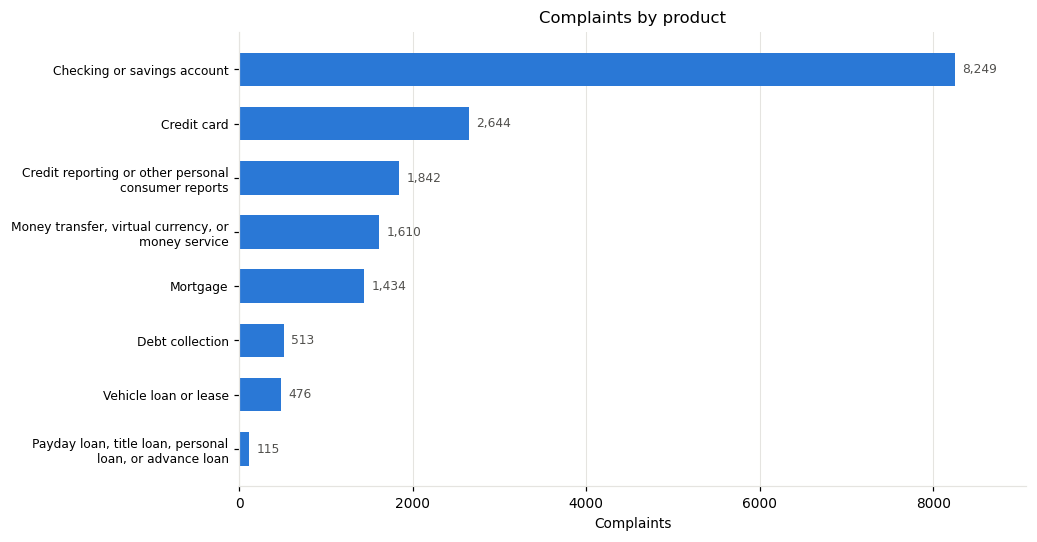

Categories: 8
Largest category share: 48.9%  (a constant guess would score this)
Imbalance ratio (largest:smallest): 72:1


In [11]:
counts=cleaned["Product"].value_counts()
products=pd.DataFrame({
    "complaints":counts,
    "percent":counts.div(len(cleaned)).mul(100).round(2)
})
display(products)

ordered=counts.sort_values()
fig,ax=plt.subplots(figsize=(9.5,5))
ax.barh(np.arange(len(ordered)),ordered.values,color=BLUE,height=.62)
ax.set_yticks(np.arange(len(ordered)))
ax.set_yticklabels([fill(label,36) for label in ordered.index],fontsize=8)
ax.set_title("Complaints by product")
ax.set_xlabel("Complaints")
ax.xaxis.grid(True,color=GRID,lw=.7)
ax.set_axisbelow(True)
for i,v in enumerate(ordered.values):
    ax.annotate(f"{v:,}",(v,i),xytext=(5,0),textcoords="offset points",
                va="center",fontsize=8,color="#52514e")
ax.set_xlim(0,ordered.max()*1.1)
plt.tight_layout()
plt.show()

share=counts/len(cleaned)
print("Categories:",len(counts))
print(f"Largest category share: {share.iloc[0]*100:.1f}%  (a constant guess would score this)")
print(f"Imbalance ratio (largest:smallest): {counts.iloc[0]/counts.iloc[-1]:.0f}:1")

The categories are uneven: checking or savings accounts account for about 49% of complaints, while payday, title and personal loans account for about 0.7%, a 72:1 ratio between the largest and smallest.

Two consequences follow. Always predicting the largest category would already be right 48.9% of the time, so plain accuracy is a misleading score on this data and macro-averaged metrics should be reported instead. And the smallest category has 115 examples, which is enough to describe but thin for reliable evaluation once a holdout is carved out of it.

These counts describe this selected dataset, not the bank's overall customers.

## Complaints Over Time

Excluding partial final month 2026-02 (7 complaints through 2026-02-02)


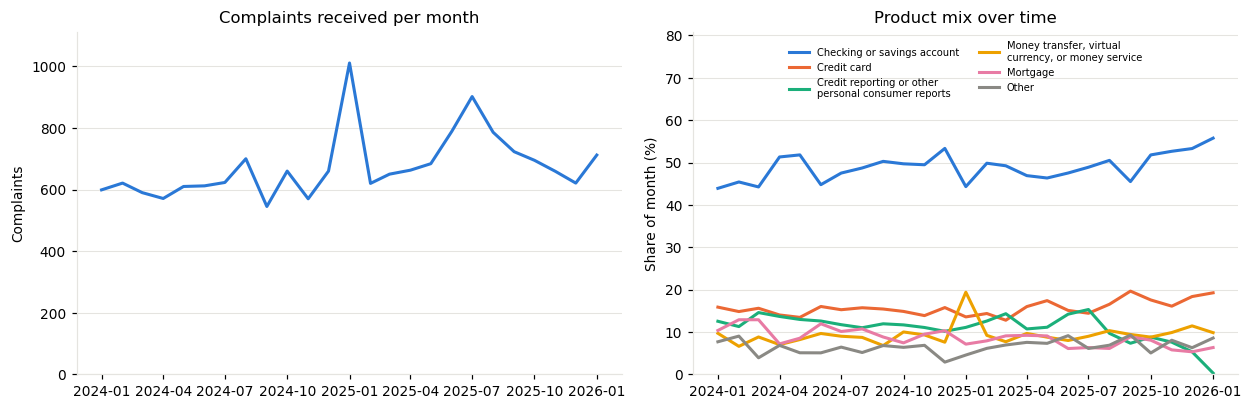

,change_in_share_pp
grp,
Checking or savings account,9.4
Credit reporting or other personal consumer reports,-8.4
Mortgage,-6.2
Credit card,2.5
"Money transfer, virtual currency, or money service",2.0
Other,0.8


In [12]:
# The collection window ends mid-month, so the final month is partial and would
# otherwise read as a collapse in volume. Restrict the time view to whole months.
_d=pd.to_datetime(cleaned["Date received"])
_last=_d.max()
if _last.day<_last.days_in_month:
    partial_month=_last.to_period("M").to_timestamp()
    ts=cleaned[cleaned["month"].ne(partial_month)]
    print(f"Excluding partial final month {partial_month:%Y-%m} "
          f"({(cleaned['month'].eq(partial_month)).sum()} complaints through {_last:%Y-%m-%d})")
else:
    ts=cleaned

monthly=ts.groupby("month").size()
top=list(counts.head(5).index)
grp=np.where(ts["Product"].isin(top),ts["Product"],"Other")
mix=(ts.assign(grp=grp).pivot_table(index="month",columns="grp",
     values="Complaint ID",aggfunc="count").fillna(0))
mix=mix.div(mix.sum(axis=1),axis=0)*100

fig,axes=plt.subplots(1,2,figsize=(11.5,3.8))
axes[0].plot(monthly.index,monthly.values,color=BLUE,lw=2)
axes[0].set_title("Complaints received per month")
axes[0].set_ylabel("Complaints")
axes[0].yaxis.grid(True,color=GRID,lw=.7)
axes[0].set_axisbelow(True)
axes[0].set_ylim(0,monthly.max()*1.1)

order=[c for c in mix.sum().sort_values(ascending=False).index if c!="Other"]+["Other"]
colors={k:(GREY if k=="Other" else SERIES[i]) for i,k in enumerate(order[:-1])}
colors["Other"]=GREY
for k in order:
    axes[1].plot(mix.index,mix[k],lw=2,color=colors[k],label=fill(k,28))
axes[1].set_title("Product mix over time")
axes[1].set_ylabel("Share of month (%)")
axes[1].yaxis.grid(True,color=GRID,lw=.7)
axes[1].set_axisbelow(True)
axes[1].legend(frameon=False,fontsize=6.5,ncol=2,loc="upper center")
axes[1].set_ylim(0,mix.max().max()*1.45)
plt.tight_layout()
plt.show()

drift=(mix.tail(3).mean()-mix.head(3).mean()).sort_values(key=abs,ascending=False)
display(drift.round(1).rename("change_in_share_pp").to_frame())

The final month of the window covers only two days and is excluded here, since seven complaints would otherwise read as a collapse in volume.

Across the complete months the volume is broadly stable, but the mix is not. Comparing the first three months with the last three, checking or savings rises about 9.4 percentage points, credit reporting falls about 8.4, and mortgage falls about 6.2.

This matters for how the data is later divided. A random split would put complaints from the same months on both sides and hide the shift, flattering any model trained on it. A split by date is the honest choice, and the credit reporting category in particular will be sparse in any recent holdout.

## Redaction

In [13]:
redaction_tokens=cleaned[text_col].str.count(REDACTION)
by_product=pd.DataFrame({
    "complaints":cleaned.groupby("Product").size(),
    "pct_with_redaction":cleaned.assign(h=redaction_tokens.gt(0)).groupby("Product")["h"].mean().mul(100).round(1),
    "redaction_share_of_words":(cleaned.assign(r=redaction_tokens).groupby("Product")["r"].sum()
                                /cleaned.groupby("Product")["word_count"].sum()).mul(100).round(1)
}).sort_values("redaction_share_of_words",ascending=False)
display(by_product)

print(f"Overall: {redaction_tokens.sum():,} redaction markers, "
      f"{redaction_tokens.sum()/cleaned['word_count'].sum()*100:.1f}% of all words, "
      f"in {redaction_tokens.gt(0).mean()*100:.1f}% of complaints")

,complaints,pct_with_redaction,redaction_share_of_words
Product,,,
"Money transfer, virtual currency, or money service",1610,95.3,7.8
Mortgage,1434,88.8,6.9
Credit reporting or other personal consumer reports,1842,80.6,6.8
Checking or savings account,8249,88.0,6.6
Credit card,2644,89.3,6.5
"Payday loan, title loan, personal loan, or advance loan",115,87.8,6.5
Vehicle loan or lease,476,84.5,6.2
Debt collection,513,77.0,5.5


Overall: 271,263 redaction markers, 6.7% of all words, in 87.7% of complaints


Redaction is heavy and uneven. Names, dates and dollar amounts are replaced with `XXXX`, so any later feature extraction should strip `X{2,}` before building a vocabulary, and approaches that depend on dates, amounts or named entities will not work on this text. The markers are retained in the CSV so that decision stays open.

## Distinctive Vocabulary

Which words separate the categories? Raw frequency would just return common English, so this ranks each term by a log-odds ratio with an informative Dirichlet prior: how much more a term is used in one category than the corpus as a whole, scaled by how reliably that difference is estimated. This is a descriptive statistic, not a trained model.

In [14]:
STOP=set("""the a an and or but if then than that this these those i me my we our you your he she it its they them their
was were is are be been being am do does did doing have has had having will would can could should may might must
of in on at to for with from by about into over after before under again further not no nor so too very just
as until while during because about against between through s t don now also got get getting one two three back
said says say told tell called call calling went go going come came take took make made want wanted need needed
time day days week weeks month months year years account accounts wells fargo bank""".split())
TOKEN=re.compile(r"[a-z][a-z']{2,}")

def tokens(s):
    return [t for t in TOKEN.findall(REDACTION.sub(" ",s).lower()) if t not in STOP]

doc_tokens=cleaned[text_col].map(tokens)
total=Counter()
per_product={p:Counter() for p in cleaned["Product"].unique()}
for p,toks in zip(cleaned["Product"],doc_tokens):
    c=Counter(toks)
    total.update(c)
    per_product[p].update(c)

MIN_COUNT=40
vocab=[w for w,c in total.items() if c>=MIN_COUNT]
a=np.array([total[w] for w in vocab],dtype=float)
a0=a.sum()
y_all=a.copy()
n_all=y_all.sum()
print(f"{len(doc_tokens):,} complaints, {len(total):,} distinct tokens, "
      f"{len(vocab):,} kept at count >= {MIN_COUNT}")

rows={}
for p,counter in per_product.items():
    y=np.array([counter[w] for w in vocab],dtype=float)
    n=y.sum()
    rest=y_all-y
    n_rest=n_all-n
    lo=(np.log((y+a)/(n+a0-y-a))-np.log((rest+a)/(n_rest+a0-rest-a)))
    z=lo/np.sqrt(1.0/(y+a)+1.0/(rest+a))
    idx=np.argsort(z)[::-1][:12]
    rows[p]=[(vocab[i],z[i]) for i in idx]

display(pd.DataFrame({p:[w for w,_ in v] for p,v in
        sorted(rows.items(),key=lambda kv:-counts[kv[0]])}).rename_axis("rank"))

16,883 complaints, 23,047 distinct tokens, 3,526 kept at count >= 40


,Checking or savings account,Credit card,Credit reporting or other personal consumer reports,"Money transfer, virtual currency, or money service",Mortgage,Debt collection,Vehicle loan or lease,"Payday loan, title loan, personal loan, or advance loan"
rank,,,,,,,,
0,overdraft,card,reporting,wire,mortgage,debt,vehicle,interest
1,claim,credit,credit,transfer,loan,collection,repossession,loan
2,deposit,interest,consumer,money,home,validation,car,line
3,checking,balance,report,scam,foreclosure,fdcpa,auto,deferred
4,check,rewards,fcra,recipient,modification,reporting,dealership,financing
5,transactions,dispute,inaccurate,transfers,escrow,alleged,repossessed,installment
6,debit,charge,information,recall,insurance,fcra,loan,lending
7,atm,charges,usc,funds,property,creditor,warranty,payoff
8,funds,limit,section,sent,house,collect,repo,finance


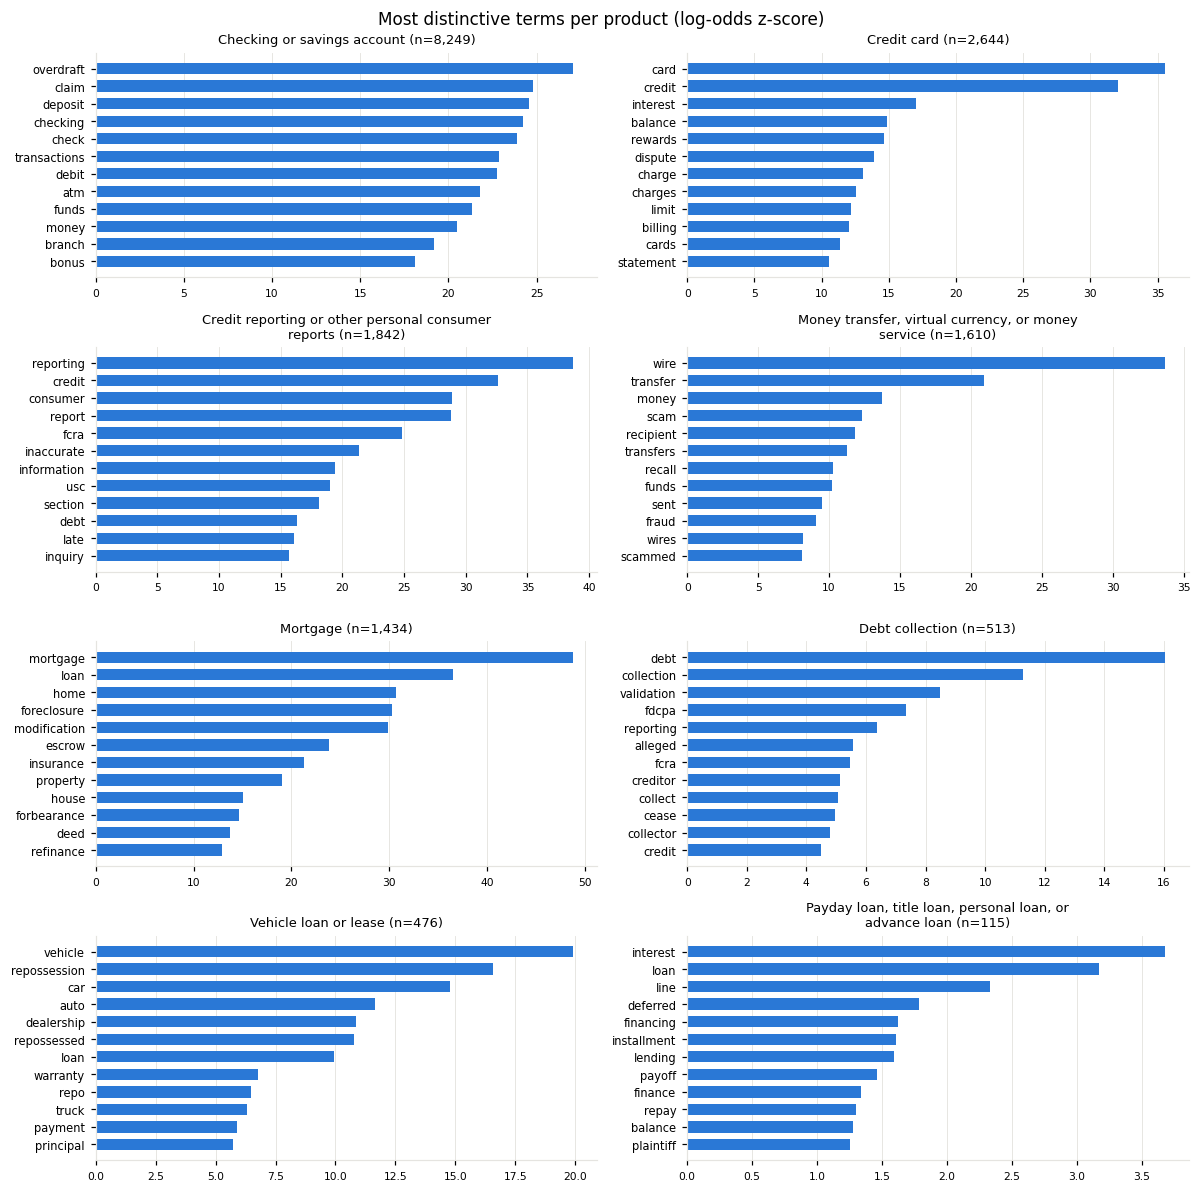

In [15]:
order=list(counts.index)
fig,axes=plt.subplots(4,2,figsize=(11,11))
for ax,p in zip(axes.ravel(),order):
    terms=rows[p][::-1]
    ax.barh(np.arange(len(terms)),[z for _,z in terms],color=BLUE,height=.65)
    ax.set_yticks(np.arange(len(terms)),[w for w,_ in terms],fontsize=7.5)
    ax.set_title(fill(f"{p} (n={counts[p]:,})",46),fontsize=8.5)
    ax.tick_params(axis="x",labelsize=7)
    ax.xaxis.grid(True,color=GRID,lw=.6)
    ax.set_axisbelow(True)
for ax in axes.ravel()[len(order):]:
    ax.axis("off")
fig.suptitle("Most distinctive terms per product (log-odds z-score)",fontsize=11)
plt.tight_layout()
plt.show()

The distinctive terms are semantically coherent and match how each product actually fails: mortgages surface `escrow`, `foreclosure` and `forbearance`; vehicle loans surface `repossession` and `dealership`; debt collection surfaces `fdcpa` and `validation`. That the vocabulary separates this cleanly without any training is the strongest evidence in this notebook that the routing task is learnable from the narrative alone.

Two overlaps are worth noting because they predict where a model will struggle. Credit reporting and debt collection share dispute and validation language, and `debt` appears among the top credit reporting terms. Checking or savings and money transfer both draw on `funds` and `money`, since Zelle and wire complaints can be filed under either. Those two pairs, not the eight categories as a whole, are where the real difficulty sits.

## Final Dataset

In [16]:
final_checks=pd.Series({
    "rows":len(cleaned),
    "columns":len(df.columns),
    "usable_narratives":cleaned[text_col].fillna("").str.strip().ne("").sum(),
    "missing_narratives":cleaned[text_col].isna().sum(),
    "empty_narratives":cleaned[text_col].fillna("").str.strip().eq("").sum(),
    "missing_products":cleaned["Product"].isna().sum(),
    "empty_products":cleaned["Product"].fillna("").str.strip().eq("").sum(),
    "duplicate_rows":cleaned[df.columns].duplicated().sum(),
    "duplicate_complaint_ids":cleaned["Complaint ID"].duplicated().sum(),
    "duplicate_normalized_narratives":cleaned[text_col].str.casefold().duplicated().sum(),
    "product_categories":cleaned["Product"].nunique()
},name="value")
display(final_checks.to_frame())
display(cleaned[df.columns].isna().sum().rename("remaining_missing").to_frame())

assert cleaned[df.columns].shape==df.shape
assert cleaned.drop(columns=[text_col,"word_count","month"]).equals(df.drop(columns=text_col))
assert cleaned[text_col].str.casefold().eq(normalized.str.casefold()).all()
assert cleaned["Product"].value_counts().equals(df["Product"].value_counts())
assert final_checks[["missing_narratives","empty_narratives","missing_products","empty_products","duplicate_rows","duplicate_complaint_ids","duplicate_normalized_narratives"]].eq(0).all()

,value
rows,16883
columns,7
usable_narratives,16883
missing_narratives,0
empty_narratives,0
missing_products,0
empty_products,0
duplicate_rows,0
duplicate_complaint_ids,0
duplicate_normalized_narratives,0


,remaining_missing
Complaint ID,0
Date received,0
Company,0
Consumer complaint narrative,0
Product,0
Narrative group ID,0
Source URL,0


In [17]:
cleaned[df.columns].to_csv("cleaned_consumer_complaints.csv",index=False,encoding="utf-8-sig")
pd.DataFrame({
    "original_rows":[len(df)],
    "cleaned_rows":[len(cleaned)],
    "rows_removed":[len(df)-len(cleaned)],
    "narratives_with_whitespace_changes":[int(changed.sum())]
})

,original_rows,cleaned_rows,rows_removed,narratives_with_whitespace_changes
0,16883,16883,0,10115
